## Section 1. Data Preparation

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr

# --- DATA LOADING AND PREPROCESSING ---
try:
    df = pd.read_csv('../data/morpheme_counts.csv')
except FileNotFoundError:
    df = pd.read_csv('morpheme_counts.csv')

# --- CALCULATION OF DERIVATION INDICES (Id) ---
# Normalization formulas based on corpus size and specific language constants
df["KZ_Id"] = df["KZ"] * 0.1
df["EN_Id"] = df["EN"] * (1000/12000)
df["RU_Id"] = df["RU"] * (1000/24000)

## Section 2. Statistical Analysis

In [10]:
# --- TABLE 3: DESCRIPTIVE STATISTICS ---
languages = ['KZ', 'EN', 'RU']

def calculate_table_3(data):
    stats = data[languages].describe().T
    stats['IQR'] = stats['75%'] - stats['25%']
    result = stats[['count', 'mean', '50%', 'std', 'min', 'max', 'IQR']].copy()
    result.columns = ['N (elements)', 'Mean', 'Median', 'SD', 'Minimum', 'Maximum', 'IQR']
    return result.T.round(2)

table_3 = calculate_table_3(df)
print("Table 3. Descriptive statistics of derivational expansion (Nd)")
display(table_3)

Table 3. Descriptive statistics of derivational expansion (Nd)


,KZ,EN,RU
N (elements),111.00,111.00,111.00
Mean,15.52,16.38,15.89
Median,9.00,9.00,9.00
SD,18.34,19.73,18.65
Minimum,1.00,1.00,1.00
Maximum,117.00,133.00,118.00
IQR,15.50,17.50,17.00


## Section 3: Data Visualization

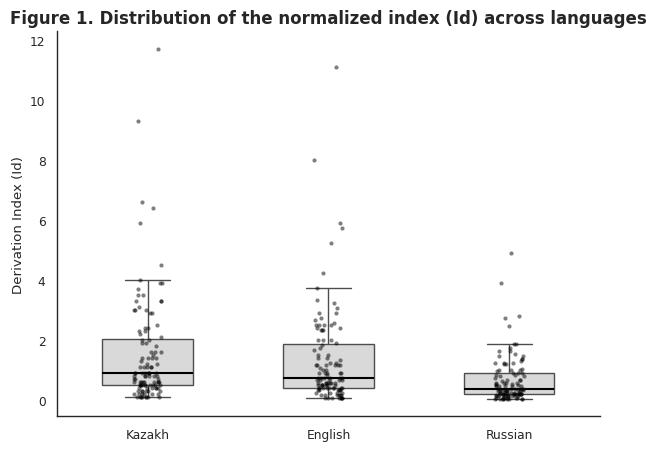

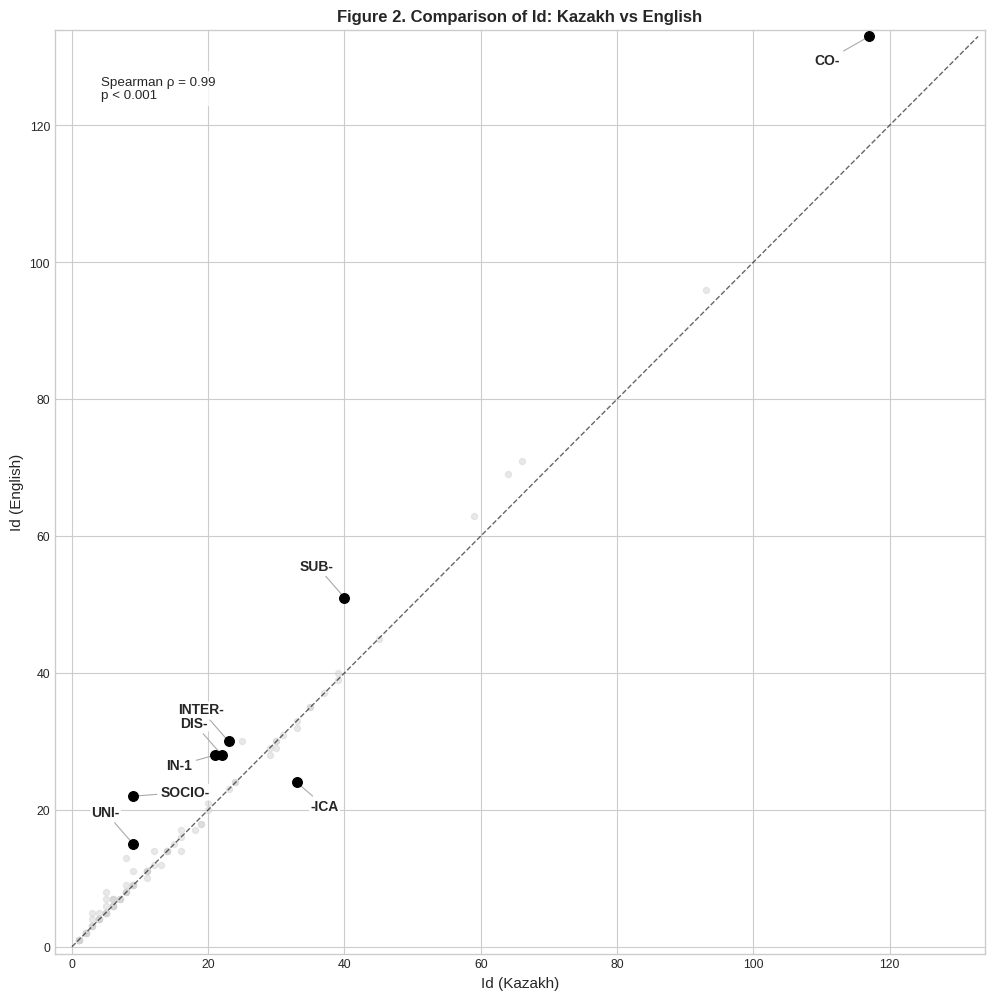

In [11]:
# ---  FIGURE 1: DISTRIBUTION BOXPLOT ---
df_long_id = df.melt(
    id_vars="Morpheme",
    value_vars=["KZ_Id", "EN_Id", "RU_Id"],
    var_name="Language",
    value_name="Id"
)
df_long_id["Language"] = df_long_id["Language"].map({"KZ_Id": "Kazakh", "EN_Id": "English", "RU_Id": "Russian"})

sns.set(style="white", context="paper")
plt.figure(figsize=(7,5))
sns.boxplot(data=df_long_id, x="Language", y="Id", width=0.5, showfliers=False, color="#D9D9D9",
            boxprops=dict(edgecolor="#4D4D4D"), whiskerprops=dict(color="#4D4D4D"),
            capprops=dict(color="#4D4D4D"), medianprops=dict(color="#000000", linewidth=1.5))
sns.stripplot(data=df_long_id, x="Language", y="Id", color="#000000", alpha=0.5, jitter=0.08, size=3)
plt.title('Figure 1. Distribution of the normalized index (Id) across languages', fontsize=12, weight='bold')
plt.ylabel("Derivation Index (Id)")
plt.xlabel("")
sns.despine()


if not os.path.exists('../results'): os.makedirs('../results', exist_ok=True)
plt.savefig('Figure_1_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ---  FIGURE 2: CROSS-LINGUISTIC COMPARISON (KZ vs EN) ---
plt.figure(figsize=(12, 12))
plt.style.use('seaborn-v0_8-whitegrid')

rho, p_val = spearmanr(df['KZ'], df['EN'])
plt.scatter(df['KZ'], df['EN'], s=20, color='lightgrey', alpha=0.5)

threshold = 5.5
outliers = df[abs(df['KZ'] - df['EN']) >= threshold]
plt.scatter(outliers['KZ'], outliers['EN'], s=50, color='black', edgecolor='black', zorder=5)

max_val = max(df['KZ'].max(), df['EN'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1, alpha=0.6)

for i in range(len(outliers)):
    x, y, label = outliers.iloc[i]['KZ'], outliers.iloc[i]['EN'], outliers.iloc[i]['Morpheme']
    off_x, off_y, align = (-20 if y > x else 20), (20 if y > x else -20), 'center'

    if "SOCIO-" in label: off_x, off_y, align = 20, 0, 'left'
    elif "CO-" in label: off_x, off_y = -30, -20
    elif "IN-" in label: off_x, off_y, align = -35, -10, 'left'
    elif x < 2.5: off_x, off_y, align = 45, 15, 'left'

    plt.annotate(label, (x, y), textcoords="offset points", xytext=(off_x, off_y),
                 ha=align, fontsize=10, weight='bold',
                 bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.9),
                 arrowprops=dict(arrowstyle='-', color='darkgrey', lw=0.8))

plt.xlim(-2.5, max_val + 1)
plt.ylim(-1.0, max_val + 1)
plt.text(0.05, 0.95, f'Spearman ρ = {rho:.2f}\np < 0.001', transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Figure 2. Comparison of Id: Kazakh vs English', fontsize=12, weight='bold')
plt.xlabel('Id (Kazakh)', fontsize=11)
plt.ylabel('Id (English)', fontsize=11)


if not os.path.exists('../results'): os.makedirs('../results', exist_ok=True)
plt.savefig('Figure_2_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()